# Data Quality Diagnostics — `account_balances_daily_RAW.csv`

Companion notebook to `flawed_model_squad_draft.ipynb`. Before touching the forecast or the
rebalancing rule, this notebook quantifies what's actually wrong with the raw data: mixed
currency labels, mixed date formats, duplicated (account, date) rows, missing values, and
negative balances — and cross-checks the negative-balance finding against the squad's
hardcoded threshold rule.

Nothing here is fixed "silently" — each section shows the count, the mechanism, and (where
there's a safe fix) the corrected column, so the numbers can be reused directly in the Part 1
write-up.

In [54]:
import pandas as pd
import numpy as np
import re

pd.set_option("display.width", 120)

accounts = pd.read_csv("accounts.csv")
raw = pd.read_csv(
    "account_balances_daily_RAW.csv",
    dtype={"account_id": str, "date": str, "balance": float, "currency": str},
)

print("accounts:", accounts.shape)
print("raw balances:", raw.shape)
raw.head()

accounts: (6, 4)
raw balances: (1668, 6)


,date,account_id,currency,balance,inflow,outflow
0,2025-08-14,ACC-003,COP,2.987755e+09,1.061766e+08,1.048038e+08
1,2025-05-06,ACC-006,USD,1.483432e+05,1.906440e+03,6.631360e+03
2,2025-08-30,ACC-001,COP,2.422127e+09,3.506431e+07,6.704482e+07
3,22/05/2025,ACC-001,COP,2.596891e+09,1.367743e+08,1.115069e+08
4,2025-07-03,ACC-005,Mexican Peso,1.368157e+08,4.004622e+06,3.866024e+06


## 1. Currency label audit

The same three currencies are written 9 different ways (mixed case + full names). Nothing
downstream normalizes this, so any FX-aware aggregation (or even a simple `groupby("currency")`)
silently splits one currency into up to three buckets.

In [55]:
print("Raw unique currency labels:")
print(sorted(raw["currency"].unique()))

CURRENCY_MAP = {
    "cop": "COP", "colombian peso": "COP",
    "usd": "USD", "us dollar": "USD",
    "mxn": "MXN", "mexican peso": "MXN",
}
raw["currency_norm"] = raw["currency"].str.strip().str.lower().map(CURRENCY_MAP)

unmapped = raw.loc[raw["currency_norm"].isna(), "currency"].unique()
assert len(unmapped) == 0, f"unmapped currency labels found: {unmapped}"

print("\nNormalized currency counts:")
print(raw["currency_norm"].value_counts())

Raw unique currency labels:
['COP', 'Colombian Peso', 'MXN', 'Mexican Peso', 'US Dollar', 'USD', 'cop', 'mxn', 'usd']

Normalized currency counts:
currency_norm
USD    558
COP    556
MXN    554
Name: count, dtype: int64


## 2. Date format audit

`date` mixes at least three layouts: `YYYY-MM-DD`, `DD/MM/YYYY`, and `MM-DD-YYYY`. The squad's
notebook calls `pd.to_datetime(errors="coerce")` on the whole column and then `dropna()`s
whatever fails, with a comment saying "a few dates don't parse, we just drop those". This
section shows it's not "a few".

In [56]:
def classify_date_format(s):
    if pd.isna(s):
        return "missing"
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", s):
        return "iso_YYYY-MM-DD"
    m = re.fullmatch(r"(\d{2})/(\d{2})/(\d{4})", s)
    if m:
        a, b = int(m.group(1)), int(m.group(2))
        if a > 12 >= b: return "slash_DD/MM/YYYY"
        if b > 12 >= a: return "slash_MM/DD/YYYY"
        return "slash_ambiguous (both<=12)"
    m = re.fullmatch(r"(\d{2})-(\d{2})-(\d{4})", s)
    if m:
        a, b = int(m.group(1)), int(m.group(2))
        if a > 12 >= b: return "dash2_DD-MM-YYYY"
        if b > 12 >= a: return "dash2_MM-DD-YYYY"
        return "dash2_ambiguous (both<=12)"
    return "other/unrecognized"

raw["date_format"] = raw["date"].apply(classify_date_format)
raw["date_format"].value_counts()

date_format
iso_YYYY-MM-DD                1375
slash_DD/MM/YYYY               106
dash2_MM-DD-YYYY                78
slash_ambiguous (both<=12)      64
dash2_ambiguous (both<=12)      45
Name: count, dtype: int64

In [57]:
print("Share of each format, by currency:")
print(pd.crosstab(raw["currency_norm"], raw["date_format"], normalize="index").round(2))

print("\nShare of each format, by account:")
print(pd.crosstab(raw["account_id"], raw["date_format"], normalize="index").round(2))

Share of each format, by currency:
date_format    dash2_MM-DD-YYYY  dash2_ambiguous (both<=12)  iso_YYYY-MM-DD  slash_DD/MM/YYYY  \
currency_norm                                                                                   
COP                        0.04                        0.02            0.83              0.07   
MXN                        0.06                        0.03            0.81              0.07   
USD                        0.05                        0.04            0.83              0.05   

date_format    slash_ambiguous (both<=12)  
currency_norm                              
COP                                  0.04  
MXN                                  0.04  
USD                                  0.04  

Share of each format, by account:
date_format  dash2_MM-DD-YYYY  dash2_ambiguous (both<=12)  iso_YYYY-MM-DD  slash_DD/MM/YYYY  \
account_id                                                                                    
ACC-001                  0.03     

**No pattern by currency or account** — the proportions are essentially identical in every
group (~82-83% ISO, ~5-7% slash, ~4-6% dash, in COP/MXN/USD alike). That rules out "each bank's
export uses its own convention" as an explanation; the formats look randomly scattered.

There **is** a perfect pattern by separator, though:

In [58]:
not_day_first_slash = (raw["date_format"] == "slash_MM/DD/YYYY").sum()
not_month_first_dash = (raw["date_format"] == "dash2_DD-MM-YYYY").sum()

print("Unambiguous '/' rows that are NOT day-first:      ", not_day_first_slash, "/ 106+64 slash rows")
print("Unambiguous '-' (2-2-4) rows that are NOT month-first:", not_month_first_dash, "/ 78+45 dash rows")

Unambiguous '/' rows that are NOT day-first:       0 / 106+64 slash rows
Unambiguous '-' (2-2-4) rows that are NOT month-first: 0 / 78+45 dash rows


Zero exceptions across all 1,668 rows: every `/`-separated date is **day-first**
(`DD/MM/YYYY`), every `-`-separated (2-2-4) date is **month-first** (`MM-DD-YYYY`). That rule
also resolves the "ambiguous" rows (both parts ≤ 12), which currency/account grouping could not.

Now compare that to what the squad's `pd.to_datetime(errors="coerce")` actually does on the
whole column:

In [59]:
naive_parsed = pd.to_datetime(raw["date"], errors="coerce")
n_dropped = naive_parsed.isna().sum()

print("Rows turned into NaT by the squad's approach:", n_dropped, f"({n_dropped/len(raw):.1%} of all rows)")
print("Of the rows that DID survive, 100% ISO-formatted:",
      (raw.loc[naive_parsed.notna(), "date_format"] == "iso_YYYY-MM-DD").all())
print("Rows after dropna() (matches the squad notebook's reported shape):", naive_parsed.notna().sum())

Rows turned into NaT by the squad's approach: 293 (17.6% of all rows)
Of the rows that DID survive, 100% ISO-formatted: True
Rows after dropna() (matches the squad notebook's reported shape): 1375


So the squad's `dropna()` isn't clearing out a handful of corrupt rows — it's deleting **every
single non-ISO date**, ~17.6% of the entire dataset, for a reason that has nothing to do with
data quality and everything to do with an unhandled format. That's before any forecasting logic
even runs. Fix: parse with the separator rule instead of a blind `errors="coerce"`.

In [60]:
def parse_date_safely(s):
    if pd.isna(s):
        return pd.NaT
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", s):
        return pd.to_datetime(s, format="%Y-%m-%d")
    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", s):
        return pd.to_datetime(s, format="%d/%m/%Y")
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", s):
        return pd.to_datetime(s, format="%m-%d-%Y")
    return pd.NaT

raw["date_parsed"] = raw["date"].apply(parse_date_safely)
print("Rows recovered:      ", raw["date_parsed"].notna().sum(), "/", len(raw))
print("Rows still unparseable:", raw["date_parsed"].isna().sum())

Rows recovered:       1668 / 1668
Rows still unparseable: 0


## 3. Duplicate (account_id, date) rows

Same account reporting a balance on the same calendar day more than once. If these aren't
resolved before sorting/windowing, `tail(14).mean()`-style calculations pick up whichever
duplicate happens to land last — arbitrarily.

In [61]:
dup_mask = raw.duplicated(subset=["account_id", "date"], keep=False)
print(f"{dup_mask.sum()} rows involved in {dup_mask.sum() // 2} duplicated (account_id, date) pairs")

dup_pairs = raw[dup_mask].groupby(["account_id", "date"])["balance"].agg(["min", "max"])
dup_pairs["abs_diff"] = dup_pairs["max"] - dup_pairs["min"]
dup_pairs["pct_diff"] = (dup_pairs["abs_diff"] / dup_pairs["max"]).abs()
dup_pairs.sort_values("pct_diff", ascending=False).head(10)

96 rows involved in 48 duplicated (account_id, date) pairs


min           max      abs_diff  pct_diff
account_id date                                                          
ACC-002    2025-03-16  1.804520e+05  1.806279e+05  1.758830e+02  0.000974
           2025-03-20  1.880668e+05  1.882454e+05  1.785729e+02  0.000949
ACC-003    2025-06-13  2.993118e+09  2.995708e+09  2.589197e+06  0.000864
ACC-005    2025-08-25  1.038279e+08  1.039135e+08  8.558267e+04  0.000824
ACC-001    2025-05-16  2.470397e+09  2.472401e+09  2.003724e+06  0.000810
ACC-005    2025-04-02  1.587968e+08  1.589208e+08  1.239752e+05  0.000780
ACC-002    09-18-2025  7.962292e+04  7.968435e+04  6.142831e+01  0.000771
ACC-004    2025-01-16  6.115872e+07  6.119923e+07  4.050944e+04  0.000662
ACC-001    2025-08-17  2.529604e+09  2.531208e+09  1.604289e+06  0.000634
ACC-003    2025-09-24  2.935072e+09  2.936883e+09  1.810643e+06  0.000617

These are **not** exact duplicates (`drop_duplicates()` won't catch them) — each pair reports
a *different* balance for the same account-day, i.e. two conflicting readings. This needs an
explicit resolution rule (e.g. "keep latest load", "average", "flag and investigate source")
before it feeds any rolling calculation. Flagging only here, not resolving, since the right
rule depends on which system re-wrote the row.

## 4. Missing values (nulos)

In [62]:
null_counts = raw[["balance", "inflow", "outflow"]].isna().sum()
null_pct = (null_counts / len(raw) * 100).round(1)
pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})

,n_missing,pct_missing
balance,68,4.1
inflow,65,3.9
outflow,65,3.9


In [63]:
print("Rows missing 'balance', by account:")
print(raw.loc[raw["balance"].isna(), "account_id"].value_counts())

all_missing = raw[["balance", "inflow", "outflow"]].isna().all(axis=1)
print("\nRows missing balance AND inflow AND outflow at once:", all_missing.sum())

Rows missing 'balance', by account:
account_id
ACC-003    16
ACC-004    12
ACC-001    11
ACC-006    10
ACC-005    10
ACC-002     9
Name: count, dtype: int64

Rows missing balance AND inflow AND outflow at once: 0


No single account or short date window absorbs all the nulls — they're spread across accounts,
consistent with sporadic missing feed data rather than one broken source. Still needs an explicit
imputation/exclusion decision before forecasting (the squad's notebook never makes one).

## 5. Negative balances & threshold coverage gap

In [64]:
neg = raw[raw["balance"] < 0].merge(accounts, on="account_id", how="left")
neg[["account_id", "date", "currency_norm", "balance", "bank_name", "account_type"]]

,account_id,date,currency_norm,balance,bank_name,account_type
0,ACC-005,2025-04-10,MXN,-1.618887e+08,Banco Azteca+,reserve
1,ACC-001,2025-07-18,COP,-2.615646e+09,Banco Aurora,operational
2,ACC-003,24/06/2025,COP,-2.890860e+09,Banco Sureste,reserve
3,ACC-003,2025-04-03,COP,-4.070746e+09,Banco Sureste,reserve


In [65]:
SQUAD_THRESHOLD_ACCOUNTS = {"ACC-001", "ACC-002", "ACC-004", "ACC-006"}
uncovered = set(accounts["account_id"]) - SQUAD_THRESHOLD_ACCOUNTS

print("Accounts with NO threshold in the squad's rebalancing rule:", sorted(uncovered))
print("Of those, accounts that actually show a negative balance in this data:",
      sorted(uncovered & set(neg["account_id"])))

Accounts with NO threshold in the squad's rebalancing rule: ['ACC-003', 'ACC-005']
Of those, accounts that actually show a negative balance in this data: ['ACC-003', 'ACC-005']


Only 4 rows are negative in the whole dataset, and 3 of them belong to **ACC-003** and
**ACC-005** — the two `reserve` accounts (per `accounts.csv`), which are exactly the two
accounts the squad's `THRESHOLD` dict never covers. The rebalancing rule has no visibility into
the accounts where a shortfall has already happened. This is a coverage gap in the rule, not
noise in the data.

## 6. Summary

In [66]:
summary = {
    "total_rows": len(raw),
    "rows_dropped_by_squad_date_parsing": int(n_dropped),
    "pct_rows_dropped_by_squad_date_parsing": round(float(n_dropped) / len(raw) * 100, 1),
    "duplicated_account_date_pairs": int(dup_mask.sum() // 2),
    "rows_missing_balance": int(raw["balance"].isna().sum()),
    "rows_missing_inflow_or_outflow": int(raw[["inflow", "outflow"]].isna().any(axis=1).sum()),
    "rows_negative_balance": int((raw["balance"] < 0).sum()),
    "accounts_without_threshold_rule": sorted(uncovered),
}
for k, v in summary.items():
    print(f"{k}: {v}")

total_rows: 1668
rows_dropped_by_squad_date_parsing: 293
pct_rows_dropped_by_squad_date_parsing: 17.6
duplicated_account_date_pairs: 48
rows_missing_balance: 68
rows_missing_inflow_or_outflow: 126
rows_negative_balance: 4
accounts_without_threshold_rule: ['ACC-003', 'ACC-005']


### Takeaways for Part 1

- **Currency labels** — 9 spellings of 3 currencies; must normalize before any grouping or FX work.
- **Date parsing** — the squad's `errors="coerce"` + `dropna()` throws away ~17.6% of all rows,
  not because they're corrupt but because they're not ISO-formatted. The separator alone
  (`/` = day-first, `-` = month-first) recovers 100% of them with zero ambiguity.
- **Duplicates** — 96 rows sit in conflicting (account, date) pairs with two different reported
  balances; needs a resolution rule before any rolling window touches them.
- **Missing values** — ~4-5% of rows are missing balance/inflow/outflow, spread across accounts
  rather than concentrated in one place.
- **Negative balances** — rare (4 rows) but concentrated in the two reserve accounts that the
  squad's threshold rule doesn't monitor at all — a rule-coverage gap, not a data artifact.

## 7. Effect of the fix on the daily series

Section 2 showed the separator rule recovers all 1,668 rows. This checks what that buys on the
actual time series: does fixing the parsing also fix the apparent gaps in the daily
balance/inflow/outflow series, or was that a separate problem?

In [67]:
naive_sorted = (
    raw.assign(date_naive=naive_parsed)
    .dropna(subset=["date_naive"])
    .sort_values(["account_id", "date_naive"])
)
gap_naive = naive_sorted.groupby("account_id")["date_naive"].diff().dt.days

fixed_sorted = raw.dropna(subset=["date_parsed"]).sort_values(["account_id", "date_parsed"])
gap_fixed = fixed_sorted.groupby("account_id")["date_parsed"].diff().dt.days

print(f"Naive parsing ({len(naive_sorted)} rows) -- day-gap distribution:")
print(gap_naive.fillna(1).value_counts().sort_index())
print()
print(f"Fixed parsing ({len(fixed_sorted)} rows) -- day-gap distribution:")
print(gap_fixed.fillna(1).value_counts().sort_index())
print()
print(
    "Duplicate (account_id, date_parsed) pairs remaining in the fixed series:",
    fixed_sorted.duplicated(subset=["account_id", "date_parsed"], keep=False).sum(),
)

Naive parsing (1375 rows) -- day-gap distribution:
date_naive
0.0      38
1.0    1104
2.0     190
3.0      38
4.0       5
Name: count, dtype: int64

Fixed parsing (1668 rows) -- day-gap distribution:
date_parsed
0.0      48
1.0    1620
Name: count, dtype: int64

Duplicate (account_id, date_parsed) pairs remaining in the fixed series: 96


The naive `errors="coerce"` series isn't just missing 17.6% of rows — it also bakes in fake
multi-day gaps (2, 3, even 4 days between consecutive readings) into what should be a clean
daily series, because whichever non-ISO row would have filled that gap got dropped. After the
fix, every gap is exactly 1 day except the 96 rows still involved in the (account_id, date)
duplicates from Section 3 (0-day gap) — every account now has an unbroken daily series.

Practically: any day-over-day change/anomaly check run on the naive series was sometimes
comparing balances up to 4 calendar days apart and treating that as a 1-day move — inflating
"anomalies" that are really just multi-day accumulation. For the plot below we resolve the 96
duplicate rows with a simple mean, for visualization only — that is not the resolution rule
Section 3 flagged as still-needed.

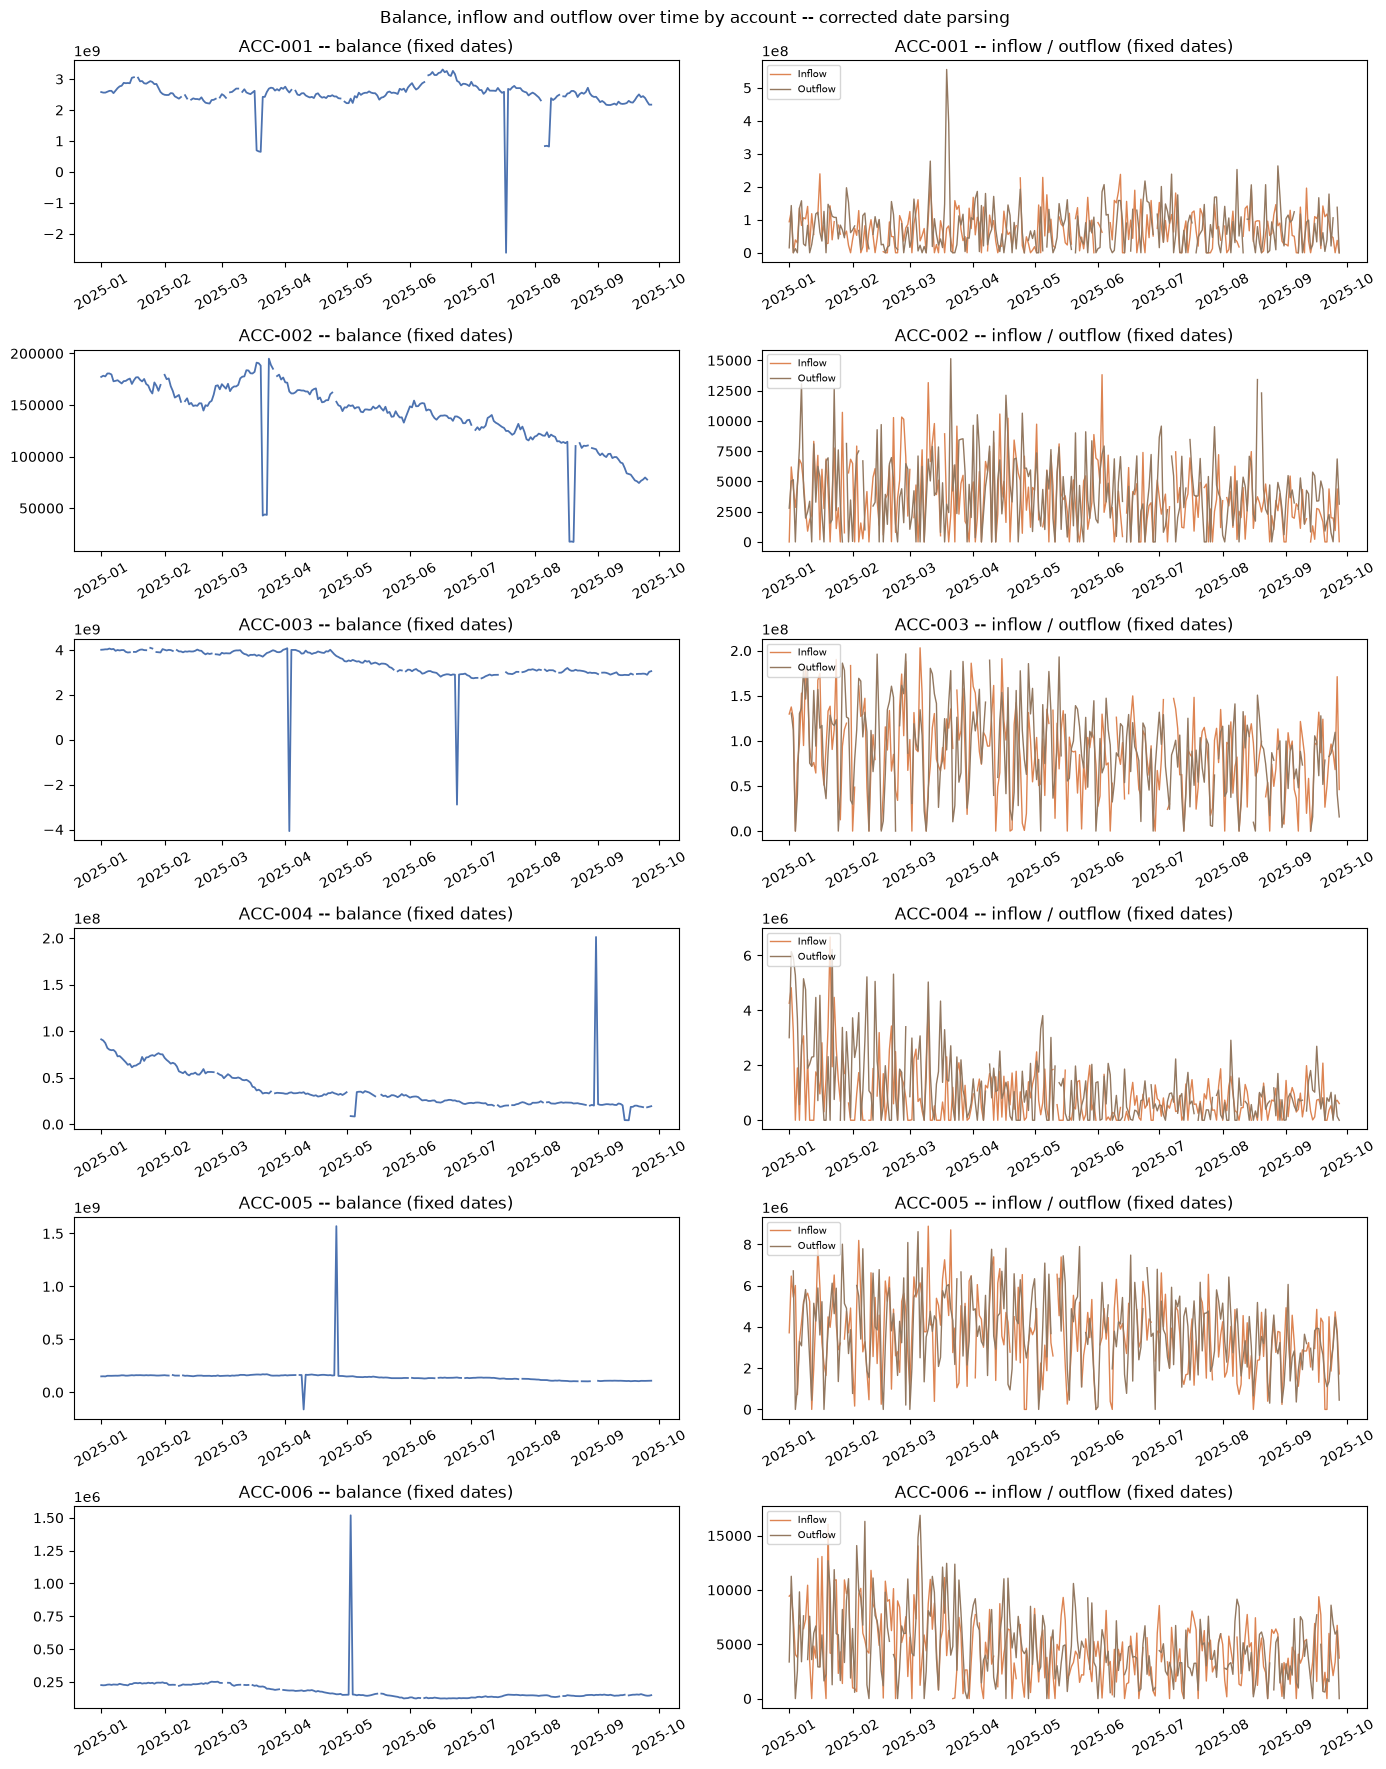

In [68]:
import matplotlib.pyplot as plt

plot_df = (
    fixed_sorted
    .groupby(["account_id", "date_parsed"], as_index=False)
    .agg(balance=("balance", "mean"), inflow=("inflow", "mean"), outflow=("outflow", "mean"))
    .sort_values(["account_id", "date_parsed"])
)

accounts_list = plot_df["account_id"].unique()
fig, axes = plt.subplots(len(accounts_list), 2, figsize=(14, 3 * len(accounts_list)))
for row, acc in enumerate(accounts_list):
    sub = plot_df[plot_df.account_id == acc]
    ax_bal, ax_flow = axes[row]

    ax_bal.plot(sub["date_parsed"], sub["balance"], color="#4C72B0", lw=1.3)
    ax_bal.set_title(f"{acc} -- balance (fixed dates)")
    ax_bal.tick_params(axis="x", rotation=30)

    ax_flow.plot(sub["date_parsed"], sub["inflow"], color="#DD8452", lw=1, label="Inflow")
    ax_flow.plot(sub["date_parsed"], sub["outflow"], color="#937860", lw=1, label="Outflow")
    ax_flow.set_title(f"{acc} -- inflow / outflow (fixed dates)")
    ax_flow.legend(fontsize=7, loc="upper left")
    ax_flow.tick_params(axis="x", rotation=30)

fig.suptitle("Balance, inflow and outflow over time by account -- corrected date parsing")
fig.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

## 8. Where the outliers are, and how accounts compare within the same currency

`balance` outliers are flagged on the **day-over-day change**, not the raw level — several
accounts trend up or down over the 9 months, and a level-based check on `balance` itself just
flags the entire trending region as anomalous. `inflow`/`outflow` don't carry that trend, so
they're checked on their raw daily value directly. Both use a per-account, robust (median/MAD)
z-score, since accounts differ by orders of magnitude in scale.

In [69]:
def mod_zscore(s):
    median = s.median()
    mad = (s - median).abs().median()
    if not mad or pd.isna(mad):
        return pd.Series(0.0, index=s.index)
    return 0.6745 * (s - median) / mad

Z_THRESHOLD = 3.5

outlier_df = plot_df.copy()
outlier_df["balance_change"] = outlier_df.groupby("account_id")["balance"].diff()
outlier_df["balance_zscore"] = outlier_df.groupby("account_id")["balance_change"].transform(mod_zscore)
outlier_df["balance_outlier"] = outlier_df["balance_zscore"].abs() > Z_THRESHOLD

for col in ["inflow", "outflow"]:
    outlier_df[f"{col}_zscore"] = outlier_df.groupby("account_id")[col].transform(mod_zscore)
    outlier_df[f"{col}_outlier"] = outlier_df[f"{col}_zscore"].abs() > Z_THRESHOLD

outlier_rows = []
for col, value_col in [("balance", "balance_change"), ("inflow", "inflow"), ("outflow", "outflow")]:
    flagged = outlier_df.loc[
        outlier_df[f"{col}_outlier"], ["account_id", "date_parsed", value_col, f"{col}_zscore"]
    ].rename(columns={value_col: "value", f"{col}_zscore": "zscore"})
    flagged["series"] = col
    outlier_rows.append(flagged)

outlier_summary = (
    pd.concat(outlier_rows, ignore_index=True)
    .merge(accounts[["account_id", "currency", "bank_name"]], on="account_id", how="left")
    .sort_values(["currency", "account_id", "series", "date_parsed"])
)
print(f"Total outlier points flagged: {len(outlier_summary)}")
print(outlier_summary.groupby(["currency", "account_id", "series"]).size())
outlier_summary

Total outlier points flagged: 59
currency  account_id  series 
COP       ACC-001     balance     5
                      outflow     2
          ACC-003     balance     4
MXN       ACC-004     balance    12
                      inflow      5
                      outflow    10
          ACC-005     balance     4
USD       ACC-002     balance     6
                      inflow      2
                      outflow     1
          ACC-006     balance     5
                      inflow      1
                      outflow     2
dtype: int64


,account_id,date_parsed,value,zscore,series,currency,bank_name
0,ACC-001,2025-03-18,-1.923775e+09,-26.757737,balance,COP,Banco Aurora
1,ACC-001,2025-03-21,1.777413e+09,24.728470,balance,COP,Banco Aurora
2,ACC-001,2025-07-18,-5.202134e+09,-72.362088,balance,COP,Banco Aurora
3,ACC-001,2025-07-19,5.297899e+09,73.700984,balance,COP,Banco Aurora
4,ACC-001,2025-08-09,1.563001e+09,21.745844,balance,COP,Banco Aurora
44,ACC-001,2025-03-19,5.557494e+08,7.001015,outflow,COP,Banco Aurora
45,ACC-001,2025-03-20,3.929651e+08,4.695332,outflow,COP,Banco Aurora
11,ACC-003,2025-04-03,-8.146956e+09,-171.821901,balance,COP,Banco Sureste
12,ACC-003,2025-04-04,8.072364e+09,170.391315,balance,COP,Banco Sureste
13,ACC-003,2025-06-24,-5.790151e+09,-122.095424,balance,COP,Banco Sureste


### Currency-grouped view

Two accounts share each currency (see `accounts.csv`). Accounts that share a currency are
literally the same unit, so — unlike the per-account grid in Section 7 — they can be overlaid
on one shared axis instead of getting separate panels. Outliers are marked with a black `x`.

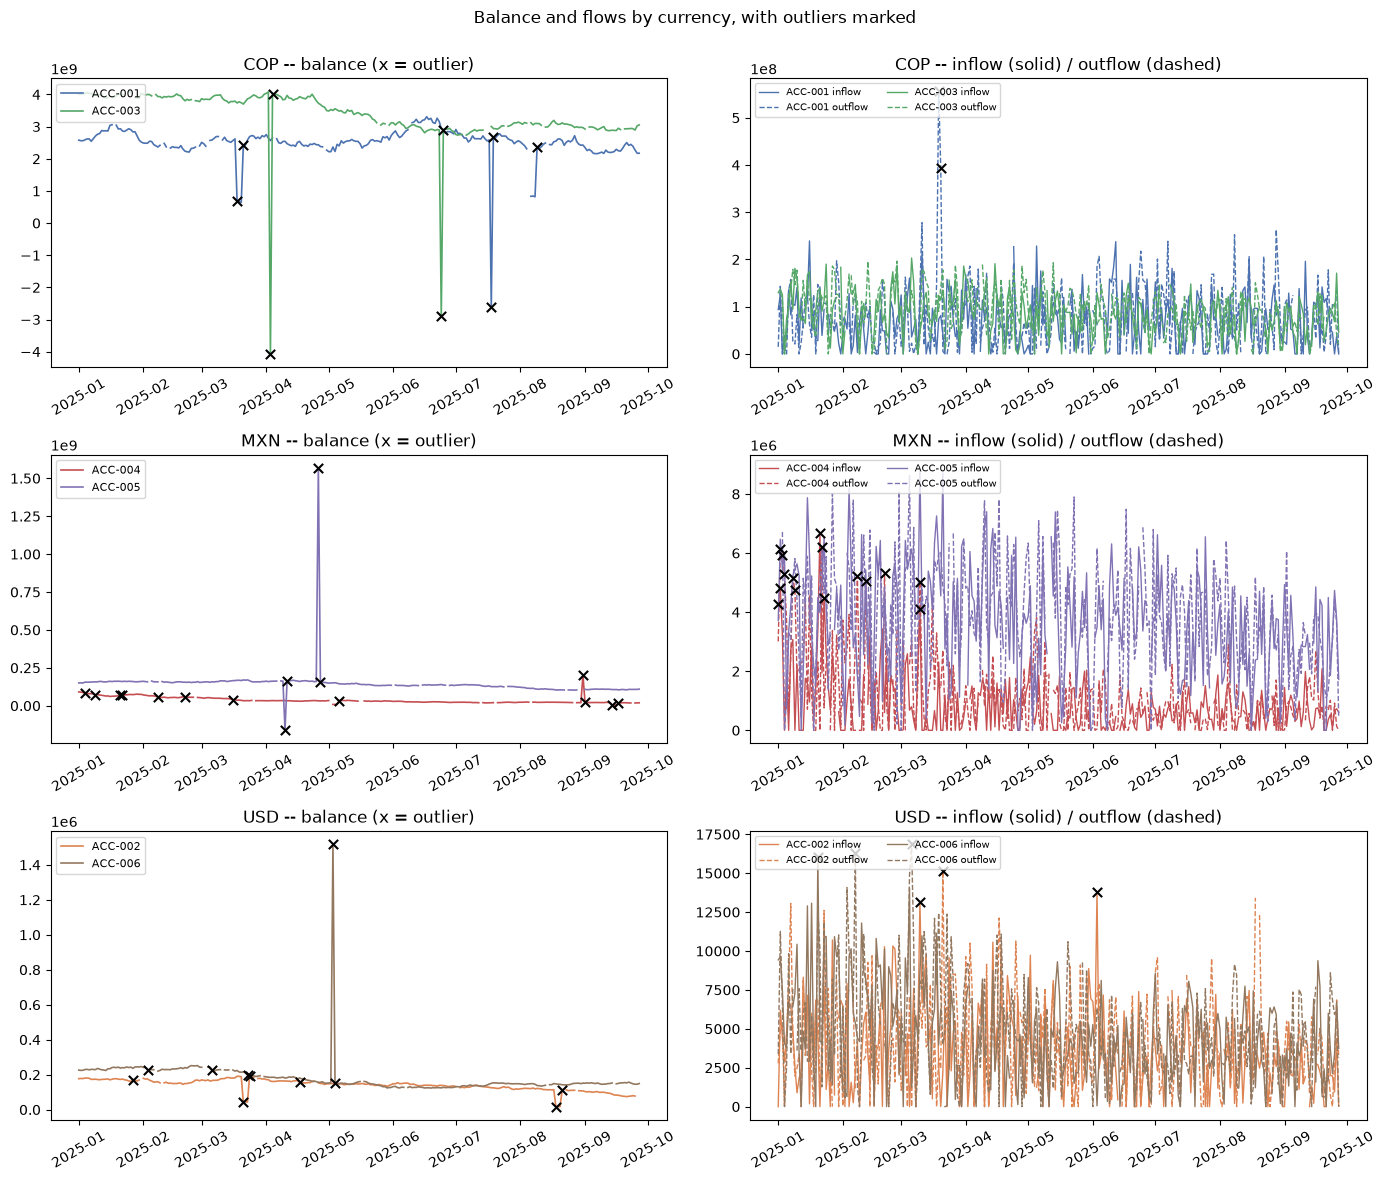

In [70]:
ACCOUNT_COLORS = {
    "ACC-001": "#4C72B0", "ACC-002": "#DD8452", "ACC-003": "#55A868",
    "ACC-004": "#C44E52", "ACC-005": "#8172B3", "ACC-006": "#937860",
}
currencies = sorted(accounts["currency"].unique())

fig, axes = plt.subplots(len(currencies), 2, figsize=(14, 4 * len(currencies)))
for row, cur in enumerate(currencies):
    acc_ids = accounts.loc[accounts["currency"] == cur, "account_id"]
    ax_bal, ax_flow = axes[row]

    for acc in acc_ids:
        sub = outlier_df[outlier_df.account_id == acc]
        color = ACCOUNT_COLORS[acc]

        ax_bal.plot(sub["date_parsed"], sub["balance"], color=color, lw=1.2, label=acc)
        out_pts = sub[sub["balance_outlier"]]
        ax_bal.scatter(out_pts["date_parsed"], out_pts["balance"], marker="x", color="black", s=45, zorder=5)

        ax_flow.plot(sub["date_parsed"], sub["inflow"], color=color, lw=1, linestyle="-", label=f"{acc} inflow")
        ax_flow.plot(sub["date_parsed"], sub["outflow"], color=color, lw=1, linestyle="--", label=f"{acc} outflow")
        for flow_col in ("inflow", "outflow"):
            out_pts = sub[sub[f"{flow_col}_outlier"]]
            ax_flow.scatter(out_pts["date_parsed"], out_pts[flow_col], marker="x", color="black", s=45, zorder=5)

    ax_bal.set_title(f"{cur} -- balance (x = outlier)")
    ax_bal.legend(fontsize=8, loc="upper left")
    ax_bal.tick_params(axis="x", rotation=30)

    ax_flow.set_title(f"{cur} -- inflow (solid) / outflow (dashed)")
    ax_flow.legend(fontsize=7, loc="upper left", ncol=2)
    ax_flow.tick_params(axis="x", rotation=30)

fig.suptitle("Balance and flows by currency, with outliers marked")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 9. Interactive daily detail (Plotly)

Same balance/flows view as Section 7, but interactive: hover for the exact daily value, zoom/pan
into any date range instead of squinting at a static PNG. Outliers from Section 8 are marked.

In [71]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

accounts_list = outlier_df["account_id"].unique()
fig = make_subplots(
    rows=len(accounts_list), cols=2,
    shared_xaxes=True,
    subplot_titles=[t for acc in accounts_list for t in (f"{acc} -- balance", f"{acc} -- inflow / outflow")],
    vertical_spacing=0.015,
)
for i, acc in enumerate(accounts_list, start=1):
    sub = outlier_df[outlier_df.account_id == acc]

    fig.add_trace(go.Scatter(x=sub["date_parsed"], y=sub["balance"], mode="lines", name="Balance",
                              line=dict(color="#4C72B0", width=1.3), showlegend=(i == 1)), row=i, col=1)
    out_pts = sub[sub["balance_outlier"]]
    fig.add_trace(go.Scatter(x=out_pts["date_parsed"], y=out_pts["balance"], mode="markers", name="Outlier",
                              marker=dict(color="black", symbol="x", size=7), showlegend=(i == 1)), row=i, col=1)

    fig.add_trace(go.Scatter(x=sub["date_parsed"], y=sub["inflow"], mode="lines", name="Inflow",
                              line=dict(color="#DD8452", width=1), showlegend=(i == 1)), row=i, col=2)
    fig.add_trace(go.Scatter(x=sub["date_parsed"], y=sub["outflow"], mode="lines", name="Outflow",
                              line=dict(color="#937860", width=1), showlegend=(i == 1)), row=i, col=2)
    for flow_col in ("inflow", "outflow"):
        out_pts = sub[sub[f"{flow_col}_outlier"]]
        fig.add_trace(go.Scatter(x=out_pts["date_parsed"], y=out_pts[flow_col], mode="markers", name="Outlier",
                                  marker=dict(color="black", symbol="x", size=7), showlegend=False), row=i, col=2)

fig.update_layout(height=260 * len(accounts_list), hovermode="x unified",
                   title="Balance, inflow and outflow -- daily detail")
fig.show()

## 10. Seasonal decomposition (weekly + ~30-day)

MSTL decomposition (`periods=[7, 30]`, `robust=True` so the extreme points flagged in Section 8
don't distort the split) on `balance`, `inflow` and `outflow` per account, extracting a weekly
and a ~30-day component simultaneously. MSTL needs a complete series, so the small
missing-value gaps from Section 4 are linearly interpolated first -- for this decomposition
only, not the imputation/exclusion decision Section 4 still needs.

Caveat on the 30-day component: it's a fixed 30-day cycle counted from the first day of data
(2025-01-01), not aligned to actual calendar months (which run 28-31 days) -- read it as "a
recurring ~monthly rhythm", not "end-of-calendar-month effect".

`*_strength` = `1 - Var(residual) / Var(component + residual)`: how much of the non-trend
variation each component explains (0 = none, 1 = perfectly periodic).

In [72]:
from statsmodels.tsa.seasonal import MSTL

def seasonal_strength(component, resid):
    resid_var = np.var(resid)
    return max(0.0, 1 - resid_var / np.var(component + resid))

series_cols = ["balance", "inflow", "outflow"]
decompositions = {}
strength_rows = []
for acc, g in plot_df.groupby("account_id"):
    g = g.set_index("date_parsed").asfreq("D")
    for col in series_cols:
        s = g[col].interpolate(limit_direction="both")
        res = MSTL(s, periods=[7, 30], stl_kwargs={"robust": True}).fit()
        decompositions[(acc, col)] = res
        strength_rows.append({
            "account_id": acc,
            "series": col,
            "weekly_strength": round(seasonal_strength(res.seasonal["seasonal_7"], res.resid), 3),
            "monthly_strength": round(seasonal_strength(res.seasonal["seasonal_30"], res.resid), 3),
        })

strength_df = pd.DataFrame(strength_rows).merge(accounts[["account_id", "currency"]], on="account_id")
strength_df = strength_df.sort_values("weekly_strength", ascending=False).reset_index(drop=True)
strength_df

,account_id,series,weekly_strength,monthly_strength,currency
0,ACC-003,outflow,0.581,0.179,COP
1,ACC-003,inflow,0.502,0.063,COP
2,ACC-005,outflow,0.467,0.028,MXN
3,ACC-005,inflow,0.411,0.095,MXN
4,ACC-006,inflow,0.361,0.049,USD
5,ACC-006,outflow,0.311,0.037,USD
6,ACC-001,outflow,0.222,0.105,COP
7,ACC-004,inflow,0.218,0.202,MXN
8,ACC-002,outflow,0.207,0.152,USD
9,ACC-001,inflow,0.153,0.025,COP


Same story as before for the weekly component -- the two **reserve** accounts (ACC-003, ACC-005)
show the clearest weekday/weekend pattern, `balance` is ~0 everywhere -- with the exact numbers
shifting slightly now that the ~30-day component absorbs some of the variance a weekly-only
model would have attributed to "week".

The ~30-day component is weaker and less clean overall, but it's noticeably higher for
**ACC-004** (`inflow` 0.20, `outflow` 0.31 -- the highest `monthly_strength` of any series) than
for any other account. That's the same account the squad's original notebook singled out as
unreliable ("the forecast for ACC-004 sometimes comes out negative or wildly different day to
day"). Unlike the weekly pattern, the shape of ACC-004's ~30-day cycle isn't a single clean
peak/trough -- it's a real, moderate, recurring rhythm that a 14-day trailing average can't see,
plausibly a contributor to that instability, but it's not on its own the whole explanation.

In [73]:
accounts_list = plot_df["account_id"].unique()
fig = make_subplots(
    rows=len(accounts_list), cols=len(series_cols),
    shared_xaxes=True,
    subplot_titles=[f"{acc} -- {col}" for acc in accounts_list for col in series_cols],
    vertical_spacing=0.02,
)
for i, acc in enumerate(accounts_list, start=1):
    for j, col in enumerate(series_cols, start=1):
        seas = decompositions[(acc, col)].seasonal["seasonal_7"]
        fig.add_trace(go.Scatter(x=seas.index, y=seas, mode="lines",
                                  line=dict(width=1, color="#55A868"), showlegend=False), row=i, col=j)
fig.update_layout(height=200 * len(accounts_list), title="Weekly seasonal component by account and series")
fig.show()

In [74]:
fig = make_subplots(
    rows=len(accounts_list), cols=len(series_cols),
    shared_xaxes=True,
    subplot_titles=[f"{acc} -- {col}" for acc in accounts_list for col in series_cols],
    vertical_spacing=0.02,
)
for i, acc in enumerate(accounts_list, start=1):
    for j, col in enumerate(series_cols, start=1):
        seas = decompositions[(acc, col)].seasonal["seasonal_30"]
        fig.add_trace(go.Scatter(x=seas.index, y=seas, mode="lines",
                                  line=dict(width=1, color="#8172B3"), showlegend=False), row=i, col=j)
fig.update_layout(height=200 * len(accounts_list), title="~30-day seasonal component by account and series")
fig.show()

Full breakdown (observed / trend / weekly / ~30-day / residual) for the strongest weekly case
and the strongest monthly case:

In [75]:
def plot_breakdown(acc, col, res):
    fig = make_subplots(rows=5, cols=1, shared_xaxes=True,
                         subplot_titles=["Observed", "Trend", "Weekly", "~30-day", "Residual"])
    fig.add_trace(go.Scatter(x=res.observed.index, y=res.observed, mode="lines", line=dict(color="#4C72B0")), row=1, col=1)
    fig.add_trace(go.Scatter(x=res.trend.index, y=res.trend, mode="lines", line=dict(color="#DD8452")), row=2, col=1)
    fig.add_trace(go.Scatter(x=res.seasonal["seasonal_7"].index, y=res.seasonal["seasonal_7"], mode="lines", line=dict(color="#55A868")), row=3, col=1)
    fig.add_trace(go.Scatter(x=res.seasonal["seasonal_30"].index, y=res.seasonal["seasonal_30"], mode="lines", line=dict(color="#8172B3")), row=4, col=1)
    fig.add_trace(go.Scatter(x=res.resid.index, y=res.resid, mode="markers", marker=dict(color="#937860", size=3)), row=5, col=1)
    fig.update_layout(height=820, title=f"MSTL decomposition -- {acc} {col}", showlegend=False)
    fig.show()

best_weekly = strength_df.sort_values("weekly_strength", ascending=False).iloc[0]
best_monthly = strength_df.sort_values("monthly_strength", ascending=False).iloc[0]

plot_breakdown(best_weekly["account_id"], best_weekly["series"], decompositions[(best_weekly["account_id"], best_weekly["series"])])
plot_breakdown(best_monthly["account_id"], best_monthly["series"], decompositions[(best_monthly["account_id"], best_monthly["series"])])

## 11. ACF / PACF: identifying the seasonality and deciding whether to difference

Section 10 *decomposes* the series; this section *diagnoses* them with the autocorrelation function (ACF) and the
partial autocorrelation function (PACF), which is what decides how a model should treat trend and seasonality:

1. **Clean the input first.** ACF is not robust: one corrupt reading (a x10 or sign-flipped balance, Section 8) dominates
   the variance and distorts every lag. Points that sit > 5 robust SDs from a centred 15-day rolling median (Hampel filter) are
   masked and interpolated, as MSTL already did for the missing values.
2. **Differencing (`d`).** Difference only if ADF cannot reject a unit root **and** the difference is not over-differenced
   (ACF(1) of the difference significantly negative, the signature of differencing a series that did not need it). KPSS is reported as a cross-check.
3. **Seasonality.** On the stationary version of each series (first difference if `d = 1`, otherwise the level minus the MSTL trend),
   look for spikes at lags 7, 14, 21, 28 in the ACF/PACF. Seasonal differencing (`D`) is only warranted if the seasonal ACF stays high
   *and* differencing at lag 7 removes it; if it just pushes ACF(7) to about -0.5, the seasonality is deterministic (dummies / seasonal terms) and should not be differenced.

In [ ]:
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

warnings.filterwarnings("ignore", message="The test statistic is outside")   # KPSS p-values are truncated to [0.01, 0.10]

NLAGS = 28
SEASONAL_LAGS = (7, 14, 21, 28)


def hampel_mask(s, window=15, n_sigmas=5.0):
    """True where a value is > n_sigmas robust SDs from its centred rolling median."""
    med = s.rolling(window, center=True, min_periods=window // 2).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=window // 2).median()
    return (s - med).abs() > n_sigmas * 1.4826 * mad.replace(0, np.nan)


def daily_series(acc, col, mask=True):
    """Complete daily series (same interpolation MSTL used); with mask=True the Hampel outliers are masked and re-interpolated."""
    s = plot_df[plot_df.account_id == acc].set_index("date_parsed").asfreq("D")[col].interpolate(limit_direction="both")
    return s.mask(hampel_mask(s)).interpolate(limit_direction="both") if mask else s


rows = []
for acc in accounts_list:
    unmasked = daily_series(acc, "balance", mask=False)
    rows.append({
        "account_id": acc,
        "balance points masked": int(hampel_mask(unmasked).sum()),
        "ACF(1) of diff, unmasked": acf(unmasked.diff().dropna(), nlags=1)[1],
        "ACF(1) of diff, masked": acf(daily_series(acc, "balance").diff().dropna(), nlags=1)[1],
    })
pd.DataFrame(rows).set_index("account_id").round(3)

,balance points masked,"ACF(1) of diff, unmasked","ACF(1) of diff, masked"
account_id,,,
ACC-001,20,-0.411,0.019
ACC-002,8,-0.015,-0.038
ACC-003,8,-0.499,0.073
ACC-004,14,-0.482,0.028
ACC-005,9,-0.499,-0.051
ACC-006,7,-0.499,-0.050


Without masking, the ACF(1) of the balance's first difference is **-0.41 to -0.50 in five of the six accounts** (ACC-002 is the exception, -0.02):
each corrupt reading makes the balance jump and come back, which looks like over-differencing. Once those points are masked it falls to about 0
(**-0.05 to 0.07**). An ACF/PACF read off the unmasked series would have pointed to the wrong model, so everything below uses the masked series.

In [ ]:
rows = []
for acc in accounts_list:
    for col in series_cols:
        s = daily_series(acc, col)
        adf_p = adfuller(s, autolag="AIC", result_object=False)[1]
        kpss_p = kpss(s, regression="c", nlags="auto", result_object=False)[1]
        acf1_diff = acf(s.diff().dropna(), nlags=1)[1]
        overdiff = acf1_diff < -1.96 / np.sqrt(len(s) - 1)
        d = int(adf_p > 0.05 and not overdiff)
        rows.append({
            "account_id": acc, "series": col, "ADF p (level)": adf_p, "KPSS p (level)": kpss_p,
            "ACF(1) of diff": acf1_diff, "over-differenced?": overdiff, "d": d,
            "KPSS agrees": (kpss_p < 0.05) if d else (kpss_p >= 0.05),
        })
diff_table = pd.DataFrame(rows).set_index(["account_id", "series"])
diff_table.round(3)

ADF p (level)  KPSS p (level)  ACF(1) of diff  over-differenced?  d  KPSS agrees
account_id series                                                                                   
ACC-001    balance          0.286           0.100           0.019              False  1        False
           inflow           0.000           0.100          -0.465               True  0         True
           outflow          0.000           0.100          -0.417               True  0         True
ACC-002    balance          0.981           0.010          -0.038              False  1         True
           inflow           0.139           0.010          -0.536               True  0        False
           outflow          0.000           0.098          -0.472               True  0         True
ACC-003    balance          0.783           0.010           0.073              False  1         True
           inflow           0.039           0.010          -0.255               True  0        False
           outflow          0.082           0.010          -0.259               True  0        False
ACC-004    balance          0.058           0.010           0.028              False  1         True
           inflow           0.001           0.010          -0.475               True  0        False
           outflow          0.011           0.010          -0.475               True  0        False
ACC-005    balance          0.956           0.010          -0.051              False  1         True
           inflow           0.148           0.010          -0.398               True  0        False
           outflow          0.627           0.010          -0.427               True  0        False
ACC-006    balance          0.717           0.010          -0.050              False  1         True
           inflow           0.315           0.010          -0.445               True  0        False
           outflow          0.009           0.010          -0.366               True  0        False

- **Balance: difference once (`d = 1`) in all six accounts.** ADF cannot reject a unit root (p from 0.06 to 0.98) and KPSS agrees in five of them (ACC-001 is the one where it does not, p = 0.10). The first difference is white noise
  (ACF(1) between -0.05 and 0.07): the balance behaves like a **random walk with drift**.
- **Inflow / outflow: do not difference (`d = 0`) in any of the 12 series.** Differencing them would over-difference: the ACF(1) of the difference is -0.26 to -0.54, far below the -0.12 band.
  KPSS rejects level-stationarity in 9 of the 12, so they drift slowly; that is handled by removing the trend (the MSTL trend, as done below), not by differencing.
- KPSS p-values are truncated to the 0.01-0.10 range by the test itself, so treat them as a cross-check rather than a precise measure.

In [ ]:
# stationary version of each series: first difference if d = 1, otherwise level minus the MSTL trend
stationary = {}
for (acc, col), row in diff_table.iterrows():
    s = daily_series(acc, col)
    stationary[(acc, col)] = s.diff().dropna() if row["d"] else s - decompositions[(acc, col)].trend.reindex(s.index)


def stem_grid(values_fn, title):
    fig = make_subplots(
        rows=len(accounts_list), cols=len(series_cols), shared_xaxes=True,
        subplot_titles=[f"{acc} -- {col} ({'diff' if diff_table.loc[(acc, col), 'd'] else 'detrended'})" for acc in accounts_list for col in series_cols],
        vertical_spacing=0.02,
    )
    for i, acc in enumerate(accounts_list, start=1):
        for j, col in enumerate(series_cols, start=1):
            x = stationary[(acc, col)]
            vals = values_fn(x)[1:]
            lags = np.arange(1, len(vals) + 1)
            fig.add_trace(go.Bar(x=lags, y=vals, showlegend=False,
                                 marker_color=["#DD8452" if l in SEASONAL_LAGS else "#4C72B0" for l in lags]), row=i, col=j)
            band = 1.96 / np.sqrt(len(x))
            for sign in (1, -1):
                fig.add_hline(y=sign * band, line=dict(color="#C44E52", width=1, dash="dot"), row=i, col=j)
    fig.update_layout(height=200 * len(accounts_list), title=title, bargap=0.3)
    fig.update_yaxes(range=[-0.6, 0.6])
    return fig


stem_grid(lambda x: acf(x, nlags=NLAGS, fft=True), "ACF of the stationary series (orange = lags 7/14/21/28, dotted = 95% white-noise band)").show()

In [ ]:
stem_grid(lambda x: pacf(x, nlags=NLAGS, method="ywm"), "PACF of the stationary series (orange = lags 7/14/21/28, dotted = 95% white-noise band)").show()

Reading the two grids (the dotted lines are the 95% white-noise band, about +/-0.12):

- **Balance (differenced):** ACF and PACF stay inside the band at almost every lag, with no spike at 7, 14, 21 or 28. No AR/MA structure and no weekly pattern. The exception is **ACC-004**, whose differenced balance keeps some autocorrelation (7 of 28 lags outside the band, Ljung-Box p = 0.001).
- **Inflow / outflow of ACC-003, ACC-005 and ACC-006:** the ACF is a clean comb, with spikes at 7, 14, 21 and 28 and negative values in between. The spikes hardly decay (ACC-003 inflow: 0.41, 0.35, 0.34; ACC-005 outflow: 0.41, 0.39, 0.36), which is what a **stable, deterministic weekly pattern** looks like. The PACF is significant at lag 7 in five of these six series (0.16 to 0.35; ACC-006 outflow sits right at the band, 0.12), but it is not a single clean cut-off: some short lags (2 to 5) and lag 14 are significant too, as expected when a weekday effect shapes the whole week.

In [ ]:
def spike(a, lag):
    """ACF at a seasonal lag minus the mean of its non-seasonal neighbours (lag-2, lag-1, lag+1, lag+2): how much it stands out."""
    return a[lag] - np.mean([a[lag + k] for k in (-2, -1, 1, 2) if lag + k <= NLAGS])


rows = []
for (acc, col), x in stationary.items():
    band = 1.96 / np.sqrt(len(x))
    a, p = acf(x, nlags=NLAGS, fft=True), pacf(x, nlags=NLAGS, method="ywm")
    spikes = [spike(a, l) for l in SEASONAL_LAGS]
    rows.append({
        "account_id": acc, "series": col, "d": diff_table.loc[(acc, col), "d"],
        "ACF(7)": a[7], "PACF(7)": p[7], "ACF(14)": a[14], "ACF(21)": a[21],
        "spike at 7": spikes[0], "seasonal spikes (of 4)": sum(sp > band for sp in spikes),
        "Ljung-Box p (lag 7)": acorr_ljungbox(x, lags=[7])["lb_pvalue"].iloc[0],
        "ACF(7) after lag-7 diff": acf(x.diff(7).dropna(), nlags=7, fft=True)[7],
    })
seasonal_table = pd.DataFrame(rows).set_index(["account_id", "series"])
band = 1.96 / np.sqrt(270)
seasonal_table["weekly seasonality?"] = (seasonal_table["spike at 7"] > band) & (seasonal_table["seasonal spikes (of 4)"] >= 2)
seasonal_table["D"] = ((seasonal_table["ACF(7)"] > 0.5) & (seasonal_table["ACF(7) after lag-7 diff"] > -0.25)).astype(int)
seasonal_table.round(3)

d  ACF(7)  PACF(7)  ACF(14)  ACF(21)  spike at 7  seasonal spikes (of 4)  Ljung-Box p (lag 7)  \
account_id series                                                                                                   
ACC-001    balance  1   0.105    0.112   -0.140    0.023       0.102                       0                0.449   
           inflow   0   0.031    0.028    0.052    0.074       0.038                       0                0.784   
           outflow  0   0.190    0.160    0.105    0.098       0.176                       2                0.001   
ACC-002    balance  1  -0.017   -0.019    0.110   -0.074      -0.000                       0                0.940   
           inflow   0   0.032    0.014    0.140    0.016       0.100                       1                0.424   
           outflow  0  -0.004   -0.008    0.147    0.115       0.011                       3                0.538   
ACC-003    balance  1  -0.018   -0.037   -0.037   -0.024      -0.029                       0                0.151   
           inflow   0   0.409    0.286    0.352    0.335       0.401                       4                0.000   
           outflow  0   0.408    0.212    0.432    0.471       0.413                       4                0.000   
ACC-004    balance  1  -0.070   -0.116   -0.146    0.094      -0.140                       1                0.001   
           inflow   0   0.084    0.023   -0.094    0.153       0.107                       0                0.001   
           outflow  0  -0.080   -0.061   -0.078    0.055      -0.131                       0                0.106   
ACC-005    balance  1   0.002    0.030   -0.076    0.021      -0.034                       0                0.254   
           inflow   0   0.283    0.235    0.233    0.321       0.312                       4                0.000   
           outflow  0   0.410    0.348    0.393    0.357       0.465                       4                0.000   
ACC-006    balance  1   0.008    0.007    0.020    0.036      -0.020                       0                0.588   
           inflow   0   0.229    0.164    0.204    0.284       0.222                       4                0.000   
           outflow  0   0.199    0.118    0.174    0.251       0.179                       4                0.000   

                    ACF(7) after lag-7 diff  weekly seasonality?  D  
account_id series                                                    
ACC-001    balance                   -0.350                False  0  
           inflow                    -0.495                False  0  
           outflow                   -0.440                 True  0  
ACC-002    balance                   -0.554                False  0  
           inflow                    -0.551                False  0  
           outflow                   -0.561                False  0  
ACC-003    balance                   -0.486                False  0  
           inflow                    -0.447                 True  0  
           outflow                   -0.518                 True  0  
ACC-004    balance                   -0.466                False  0  
           inflow                    -0.385                False  0  
           outflow                   -0.481                False  0  
ACC-005    balance                   -0.456                False  0  
           inflow                    -0.471                 True  0  
           outflow                   -0.483                 True  0  
ACC-006    balance                   -0.488                False  0  
           inflow                    -0.477                 True  0  
           outflow                   -0.470                 True  0

A series counts as weekly when the spike at lag 7 (its ACF minus the mean of the neighbouring lags) exceeds the band and at least two of the four seasonal lags stand out.

- **Weekly seasonality in 7 of the 12 flow series:** inflow and outflow of ACC-003, ACC-005 and ACC-006, plus the outflow of ACC-001 (weaker: spike 0.18). **None in any balance**, nor in ACC-001 inflow, ACC-002 or ACC-004.
- **No seasonal differencing (`D = 0`) anywhere.** Differencing at lag 7 pushes ACF(7) to -0.35...-0.56, the signature of over-differencing (about -0.5), and the seasonal spikes above are flat rather than decaying toward a seasonal unit root. The weekly pattern should be modelled with **weekday dummies or a seasonal ETS**, not differenced away.
- **Practical reading:** balance = `d = 1`, no seasonality (random walk with drift); inflow/outflow = `d = 0`, `D = 0`, weekday effect where the table says so.

ACF/PACF is a conservative detector. A weekday test (Kruskal-Wallis on the cleaned panel, `src/seasonality.py`) flags 11 of the 12 flow series; ACF/PACF confirms the seven strong ones and shows what the pattern looks like.